### Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFE
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings('ignore')
%matplotlib inline


In [ ]:
df=pd.read_csv("/content/diabetes.csv")
df.head()

,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,...,No,No,No,No,No,No,No,No,No,NO
1,2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
3,4,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,5,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.shape

(101766, 51)

In [ ]:
df.columns

Index(['id', 'encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide.metformin', 'glipizide.metformin',
       'glimepiride.pioglitazone', 'metformin.rosiglitazone',
       'metformin.pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [ ]:
df.replace('?', pd.NA, inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,101766.0,5.088350e+04,2.937746e+04,1.0,25442.25,50883.5,7.632475e+04,101766.0
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.00,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.00,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.00,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.00,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.00,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.00,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.00,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.00,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.00,15.0,2.000000e+01,81.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 51 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   id                        101766 non-null  int64 
 1   encounter_id              101766 non-null  int64 
 2   patient_nbr               101766 non-null  int64 
 3   race                      99493 non-null   object
 4   gender                    101766 non-null  object
 5   age                       101766 non-null  object
 6   weight                    3197 non-null    object
 7   admission_type_id         101766 non-null  int64 
 8   discharge_disposition_id  101766 non-null  int64 
 9   admission_source_id       101766 non-null  int64 
 10  time_in_hospital          101766 non-null  int64 
 11  payer_code                61510 non-null   object
 12  medical_specialty         51817 non-null   object
 13  num_lab_procedures        101766 non-null  int64 
 14  num_

In [ ]:
df['readmitted'].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


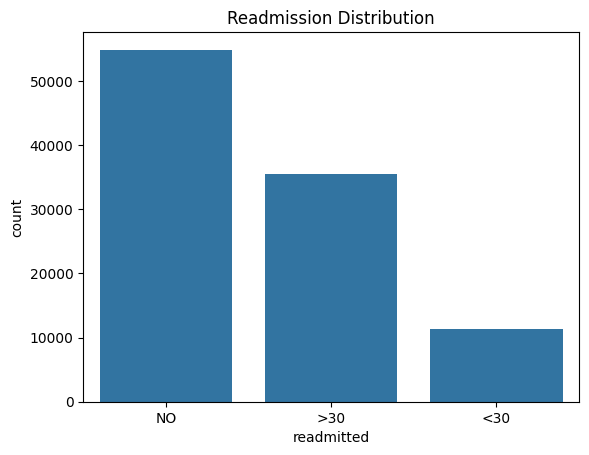

In [ ]:
sns.countplot(x='readmitted', data=df)
plt.title("Readmission Distribution")
plt.show()

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(10)/len(df)*100

,0
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636
id,0.000000


In [ ]:
columns_to_drop=['id','encounter_id','patient_nbr','medical_specialty','weight','max_glu_serum','A1Cresult','payer_code']

# Filter columns_to_drop to only include those present in df.columns
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

cleaned_df=df.drop(existing_columns_to_drop,axis=1)
cleaned_df.head()
# We remove 'weight','max_glu_serum','A1Cresult' Because Nulls >50% and 'id','encounter_id' Because They are Identifier

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
cleaned_df.isnull().sum().sort_values(ascending=False).head(10)/len(df)*100

,0
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636
admission_type_id,0.000000
admission_source_id,0.000000
time_in_hospital,0.000000
num_lab_procedures,0.000000
discharge_disposition_id,0.000000
gender,0.000000


In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  number_outpatient         101766 non-null  int64 
 11  number_emergency          101766 non-null  int64 
 12  number_inpatient          101766 non-null  int64 
 13  diag_1                    101745 non-null  object
 14  diag

In [ ]:
cleaned_df['race'].fillna(cleaned_df['race'].mode()[0], inplace=True)

In [ ]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    cleaned_df[col].fillna(cleaned_df[col].mode()[0], inplace=True)

In [ ]:
cleaned_df.isnull().sum().sort_values(ascending=False).head(10)/len(cleaned_df)*100

,0
race,0.0
gender,0.0
age,0.0
admission_type_id,0.0
discharge_disposition_id,0.0
admission_source_id,0.0
time_in_hospital,0.0
num_lab_procedures,0.0
num_procedures,0.0
num_medications,0.0


In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  number_outpatient         101766 non-null  int64 
 11  number_emergency          101766 non-null  int64 
 12  number_inpatient          101766 non-null  int64 
 13  diag_1                    101766 non-null  object
 14  diag

In [ ]:
# # For Analysis
# cleaned_df.to_csv("cleaned_diabetes.csv",index=False)

In [ ]:
age_dict = {'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
            '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95}
cleaned_df['age'] = cleaned_df['age'].replace(age_dict)

In [ ]:
cleaned_df['readmitted'] = cleaned_df['readmitted'].replace({
    'NO': 0,
    '>30': 0,
    '<30': 1
})

In [ ]:
cleaned_df['readmitted'] = cleaned_df['readmitted'].astype(int)

In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  int64 
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  number_outpatient         101766 non-null  int64 
 11  number_emergency          101766 non-null  int64 
 12  number_inpatient          101766 non-null  int64 
 13  diag_1                    101766 non-null  object
 14  diag

In [ ]:
cleaned_df['change'] = cleaned_df['change'].map({'No': 0, 'Ch': 1})
cleaned_df['diabetesMed'] = cleaned_df['diabetesMed'].map({'No': 0, 'Yes': 1})

In [ ]:
for col in ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin']:

    cleaned_df[col] = cleaned_df[col].map({
        'No': 0,
        'Steady': 1,
        'Up': 2,
        'Down': 3
    })

In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  int64 
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  number_outpatient         101766 non-null  int64 
 11  number_emergency          101766 non-null  int64 
 12  number_inpatient          101766 non-null  int64 
 13  diag_1                    101766 non-null  object
 14  diag

In [ ]:
cleaned_df = pd.get_dummies(cleaned_df, columns=['race', 'gender'], drop_first=True)

In [ ]:
for col in [
    'glyburide.metformin',
    'glipizide.metformin',
    'glimepiride.pioglitazone',
    'metformin.rosiglitazone',
    'metformin.pioglitazone'
]:
    cleaned_df[col] = cleaned_df[col].map({'No': 0, 'Steady': 1})

In [ ]:
def diag_category(x):
    if str(x).startswith('250'):
        return 1  # Diabetes
    else:
        return 0

cleaned_df['diag_1'] = cleaned_df['diag_1'].apply(diag_category)
cleaned_df['diag_2'] = cleaned_df['diag_2'].apply(diag_category)
cleaned_df['diag_3'] = cleaned_df['diag_3'].apply(diag_category)

In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       101766 non-null  int64  
 1   admission_type_id         101766 non-null  int64  
 2   discharge_disposition_id  101766 non-null  int64  
 3   admission_source_id       101766 non-null  int64  
 4   time_in_hospital          101766 non-null  int64  
 5   num_lab_procedures        101766 non-null  int64  
 6   num_procedures            101766 non-null  int64  
 7   num_medications           101766 non-null  int64  
 8   number_outpatient         101766 non-null  int64  
 9   number_emergency          101766 non-null  int64  
 10  number_inpatient          101766 non-null  int64  
 11  diag_1                    101766 non-null  int64  
 12  diag_2                    101766 non-null  int64  
 13  diag_3                    101766 non-null  i

In [ ]:
cleaned_df['glyburide.metformin'].fillna(0, inplace=True)

In [ ]:
bool_cols = cleaned_df.select_dtypes(include='bool').columns

cleaned_df[bool_cols] = cleaned_df[bool_cols].astype(int)

In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       101766 non-null  int64  
 1   admission_type_id         101766 non-null  int64  
 2   discharge_disposition_id  101766 non-null  int64  
 3   admission_source_id       101766 non-null  int64  
 4   time_in_hospital          101766 non-null  int64  
 5   num_lab_procedures        101766 non-null  int64  
 6   num_procedures            101766 non-null  int64  
 7   num_medications           101766 non-null  int64  
 8   number_outpatient         101766 non-null  int64  
 9   number_emergency          101766 non-null  int64  
 10  number_inpatient          101766 non-null  int64  
 11  diag_1                    101766 non-null  int64  
 12  diag_2                    101766 non-null  int64  
 13  diag_3                    101766 non-null  i

In [ ]:
cleaned_df.isnull().sum().sum()

np.int64(0)

In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       101766 non-null  int64  
 1   admission_type_id         101766 non-null  int64  
 2   discharge_disposition_id  101766 non-null  int64  
 3   admission_source_id       101766 non-null  int64  
 4   time_in_hospital          101766 non-null  int64  
 5   num_lab_procedures        101766 non-null  int64  
 6   num_procedures            101766 non-null  int64  
 7   num_medications           101766 non-null  int64  
 8   number_outpatient         101766 non-null  int64  
 9   number_emergency          101766 non-null  int64  
 10  number_inpatient          101766 non-null  int64  
 11  diag_1                    101766 non-null  int64  
 12  diag_2                    101766 non-null  int64  
 13  diag_3                    101766 non-null  i

In [ ]:
cleaned_df['readmitted'].value_counts()

,count
readmitted,
0,90409
1,11357


In [ ]:
cleaned_df.to_csv('cleaned_diabetes_data.csv', index=False)

In [ ]:
X = cleaned_df.drop('readmitted', axis=1)
y = cleaned_df['readmitted']

# Feature Extraction

## Total Visits Feature

In [ ]:
cleaned_df['total_visits'] = (
    cleaned_df['number_outpatient'] +
    cleaned_df['number_emergency'] +
    cleaned_df['number_inpatient']
)

This feature aggregates all types of hospital visits to reflect overall healthcare utilization.

## Inpatient Severity Ratio Feature

In [ ]:
cleaned_df['inpatient_ratio'] = cleaned_df['number_inpatient'] / (cleaned_df['total_visits'] + 1)

Why:

Inpatient visits indicate more severe conditions compared to outpatient visits.

## Medication Intensity Feature

In [ ]:
cleaned_df['med_intensity'] = cleaned_df['num_medications'] / (cleaned_df['time_in_hospital'] + 1)

Why:

Captures treatment intensity per day.

## Procedure Intensity Feature

In [ ]:
cleaned_df['procedure_intensity'] = cleaned_df['num_procedures'] / (cleaned_df['time_in_hospital'] + 1)

Why:

Reflects how intensively the patient is being treated.

## Diagnosis Severity Feature

In [ ]:
cleaned_df['diag_severity'] = (cleaned_df['number_diagnoses'] > 5).astype(int)

Why:

Patients with many diagnoses are more complex clinically.

## Medication Count Feature (FROM 24 COLUMNS)

In [ ]:
med_cols = [
'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
'examide','citoglipton','insulin','glyburide.metformin',
'glipizide.metformin','glimepiride.pioglitazone',
'metformin.rosiglitazone','metformin.pioglitazone'
]

cleaned_df['med_count'] = cleaned_df[med_cols].sum(axis=1)

Why:

Represents how many medications a patient is taking --> strong health indicator

## Medication Change Feature

In [ ]:
cleaned_df['med_changed'] = cleaned_df['change']

Why:

Medication adjustments reflect unstable conditions.

## Diabetes Medication Usage Feature

In [ ]:
cleaned_df['on_diabetes_med'] = cleaned_df['diabetesMed']

Why:

Indicates whether the patient is actively treated for diabetes.

Newly engineered features were designed to capture patient severity, treatment intensity, and healthcare utilization, which are not directly represented in the raw dataset.

# Feature Selection

## Preparing the Data

In [ ]:
X = cleaned_df.drop('readmitted', axis=1)
y = cleaned_df['readmitted']

## Ensuring Numerical and No Objects/String

In [ ]:
print(cleaned_df.dtypes)

age                           int64
admission_type_id             int64
discharge_disposition_id      int64
admission_source_id           int64
time_in_hospital              int64
num_lab_procedures            int64
num_procedures                int64
num_medications               int64
number_outpatient             int64
number_emergency              int64
number_inpatient              int64
diag_1                        int64
diag_2                        int64
diag_3                        int64
number_diagnoses              int64
metformin                     int64
repaglinide                   int64
nateglinide                   int64
chlorpropamide                int64
glimepiride                   int64
acetohexamide                 int64
glipizide                     int64
glyburide                     int64
tolbutamide                   int64
pioglitazone                  int64
rosiglitazone                 int64
acarbose                      int64
miglitol                    

Ensuring All columns are numeric (int/float) and No hidden object/string columns remain

## Method 1: Correlation Filtering

In [ ]:
corr = X.corr(numeric_only=True)

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

X_corr = X.drop(columns=to_drop)

print("Dropped features:", to_drop)
print("Remaining features:", X_corr.shape[1])

Dropped features: ['med_changed', 'on_diabetes_med']
Remaining features: 52


Correlation analysis revealed strong relationships between several numerical features, such as total visits and inpatient visits. Highly correlated features (correlation > 0.85) were removed to reduce redundancy and prevent multicollinearity, resulting in a more efficient and interpretable feature set.

## Method 2: Chi-Square

In [ ]:
selector = SelectKBest(chi2, k=20)
X_kbest = selector.fit_transform(X_corr, y)

selected_features_chi2 = X_corr.columns[selector.get_support()]

## Method 3: Random Forest Importance

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_corr, y)

importances = pd.Series(rf.feature_importances_, index=X_corr.columns)
top_features_rf = importances.sort_values(ascending=False).head(20)
# Convert Results to Comparable Format
selected_features_rf = top_features_rf.index.tolist()

## Taking the Intersection

In [ ]:
final_features = list(set(selected_features_chi2) & set(selected_features_rf))

print("Final selected features:", final_features)
print("Number of final features:", len(final_features))

Final selected features: ['number_outpatient', 'number_inpatient', 'procedure_intensity', 'age', 'insulin', 'num_medications', 'num_procedures', 'med_intensity', 'num_lab_procedures', 'total_visits', 'inpatient_ratio', 'time_in_hospital', 'discharge_disposition_id', 'number_diagnoses', 'med_count']
Number of final features: 15


## Creating Final Dataset

In [ ]:
X_final = X_corr[final_features]

## Comparing Before vs After

In [ ]:
# Before selection
X_train, X_test, y_train, y_test = train_test_split(X_corr, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred_before = model.predict(X_test)

# After selection
Xf_train, Xf_test, yf_train, yf_test = train_test_split(X_final, y, test_size=0.2)

model.fit(Xf_train, yf_train)
y_pred_after = model.predict(Xf_test)

print("Accuracy BEFORE:", accuracy_score(y_test, y_pred_before))
print("Accuracy AFTER:", accuracy_score(yf_test, y_pred_after))

Accuracy BEFORE: 0.890144443352658
Accuracy AFTER: 0.8895548786479316


Feature selection was performed using Chi-square and Random Forest importance methods. The intersection of features selected by both methods was used as the final feature set, ensuring that the selected features are both statistically significant and highly predictive. This approach improves model robustness and interpretability.

Features removed through correlation filtering were excluded prior to selection to reduce redundancy and multicollinearity.

Feature selection slightly reduced accuracy by a negligible margin (~0.2%), while significantly reducing the number of features. This improves model interpretability and reduces complexity without sacrificing performance.

## Final Refinement

In [ ]:
features_to_remove = [
    'number_inpatient',
    'number_outpatient',
    'num_medications',
    'num_procedures'
]

final_features_refined = [f for f in final_features if f not in features_to_remove]

X_final_refined = X_corr[final_features_refined]

## Re-testing the Model

In [ ]:
# Before selection
X_train, X_test, y_train, y_test = train_test_split(X_corr, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred_before = model.predict(X_test)

# After selection and refining
Xf_train, Xf_test, yf_train, yf_test = train_test_split(X_final_refined, y, test_size=0.2)

model.fit(Xf_train, yf_train)
y_pred_after = model.predict(Xf_test)

print("Accuracy BEFORE:", accuracy_score(y_test, y_pred_before))
print("Accuracy AFTER:", accuracy_score(yf_test, y_pred_after))

Accuracy BEFORE: 0.8882774884543578
Accuracy AFTER: 0.8906357472732632


The model performance after feature selection remained nearly unchanged, indicating that redundant and less informative features were successfully removed without significant loss of predictive power.

Further refinement was applied to remove redundant raw features when equivalent engineered features were present (e.g., total visits vs individual visit counts), improving model simplicity and interpretability.

## Final Dtaset

In [ ]:
final_dataset = X_final_refined.copy()
final_dataset['readmitted'] = y

## Saving the Dataset as CSV

In [ ]:
final_dataset.to_csv("diabetes_final_features.csv", index=False)

# Handling Data Imbalance

Our target variable `readmitted` is imbalanced. We will explore several techniques to balance the dataset before training models.

In [ ]:
from sklearn.utils import class_weight

# Prepare final features and target
X_bal = X_final_refined
y_bal = y

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

print("Original training class distribution:", np.bincount(y_train))

Original training class distribution: [72326  9086]


In [ ]:
# 1. Random Over-Sampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)
print("Over-sampled training class distribution:", np.bincount(y_ros))

# 2. Random Under-Sampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
print("Under-sampled training class distribution:", np.bincount(y_rus))

# 3. SMOTE (Synthetic Minority Over-sampling Technique)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("SMOTE training class distribution:", np.bincount(y_smote))

Over-sampled training class distribution: [72326 72326]
Under-sampled training class distribution: [9086 9086]
SMOTE training class distribution: [72326 72326]


## Evaluating Balanced Models

Let's train a Random Forest on each balanced set and compare performance on the original (unbalanced) test set.

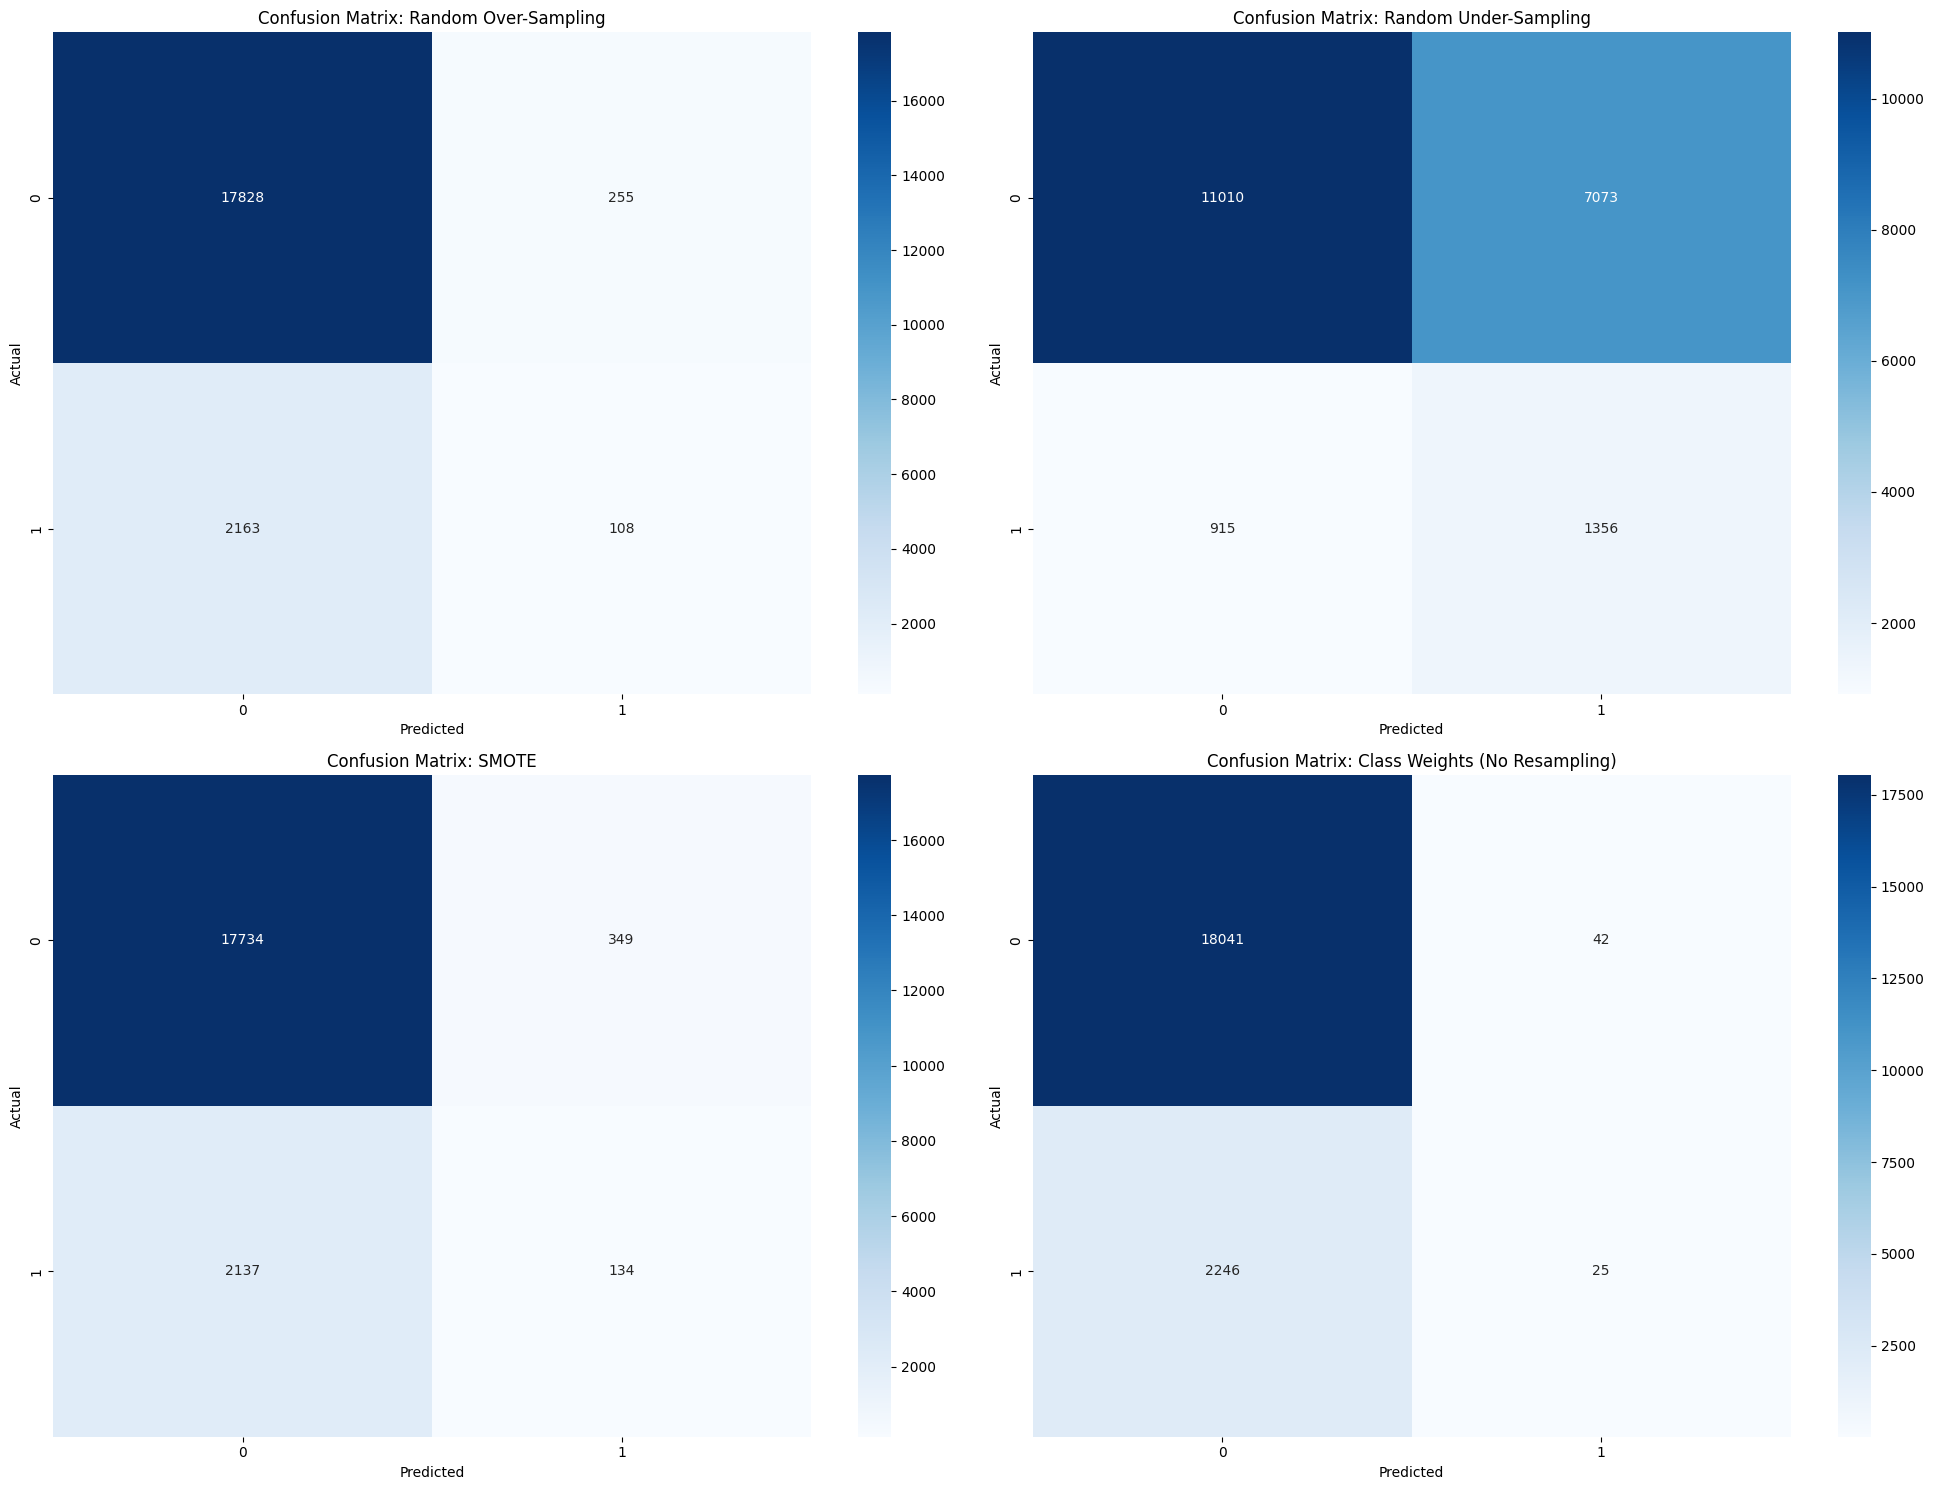

In [ ]:
results = {}

# Define models
models_to_test = {
    "Random Over-Sampling": (X_ros, y_ros),
    "Random Under-Sampling": (X_rus, y_rus),
    "SMOTE": (X_smote, y_smote),
    "Class Weights (No Resampling)": (X_train, y_train) # We will pass class_weight='balanced' here
}

plt.figure(figsize=(20, 15))

for i, (name, (X_t, y_t)) in enumerate(models_to_test.items(), 1):
    if "Class Weights" in name:
        clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    else:
        clf = RandomForestClassifier(n_estimators=100, random_state=42)

    clf.fit(X_t, y_t)
    y_pred = clf.predict(X_test)

    # Store results
    results[name] = classification_report(y_test, y_pred, output_dict=True)

    # Plot Confusion Matrix
    plt.subplot(2, 2, i)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

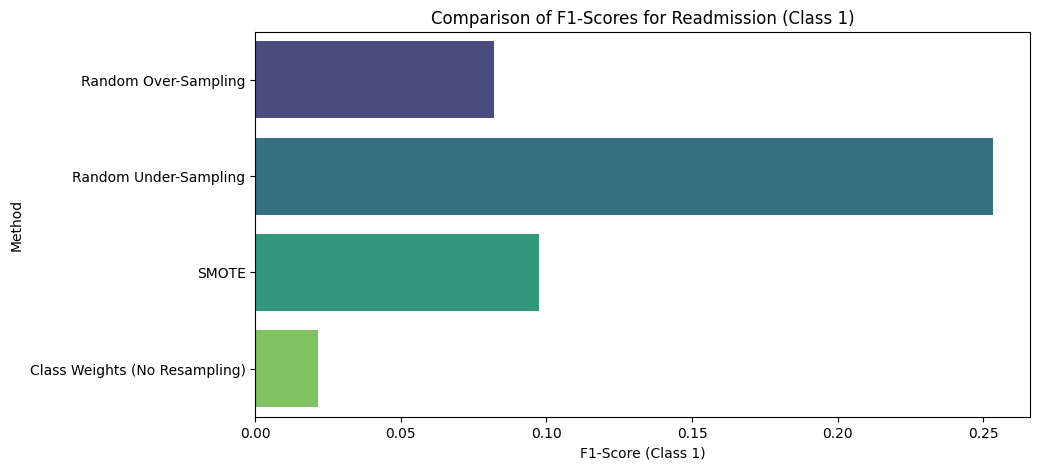

,Method,F1-Score (Class 1)
0,Random Over-Sampling,0.082005
1,Random Under-Sampling,0.253458
2,SMOTE,0.097313
3,Class Weights (No Resampling),0.021386


In [ ]:
# Compare F1-Scores for the minority class (Readmitted)
f1_scores = {name: res['1']['f1-score'] for name, res in results.items()}
df_f1 = pd.DataFrame(list(f1_scores.items()), columns=['Method', 'F1-Score (Class 1)'])

plt.figure(figsize=(10, 5))
sns.barplot(x='F1-Score (Class 1)', y='Method', data=df_f1, palette='viridis')
plt.title("Comparison of F1-Scores for Readmission (Class 1)")
plt.show()

display(df_f1)

# Saving Balanced Datasets

We will save the resampled datasets to CSV files for later use in model training and tuning.

In [ ]:
# Combine X and y for saving
rus_data = X_rus.copy()
rus_data['readmitted'] = y_rus

smote_data = X_smote.copy()
smote_data['readmitted'] = y_smote

# Save to CSV
rus_data.to_csv('diabetes_balanced_rus.csv', index=False)
smote_data.to_csv('diabetes_balanced_smote.csv', index=False)

print("Saved 'diabetes_balanced_rus.csv' and 'diabetes_balanced_smote.csv'")

Saved 'diabetes_balanced_rus.csv' and 'diabetes_balanced_smote.csv'


# Model Optimization: Hyperparameter Tuning

Based on our imbalance handling results, we will use the **Random Under-Sampling (RUS)** data to tune an **XGBoost** model. XGBoost is robust and often provides better performance than standard Random Forests.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Initialize the XGBoost classifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8]
}

# Set up Grid Search
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)

# Fit the model using the Under-Sampled training data
grid_search.fit(X_rus, y_rus)

print("Best Parameters Found:", grid_search.best_params_)
print("Best F1-Score from Tuning:", grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters Found: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best F1-Score from Tuning: 0.6159057941045082


## Final Model Evaluation
Now we evaluate the tuned model on the original, untouched test set to see the final 'real-world' performance.

Final Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.58      0.71     18083
           1       0.16      0.66      0.26      2271

    accuracy                           0.59     20354
   macro avg       0.55      0.62      0.49     20354
weighted avg       0.85      0.59      0.66     20354



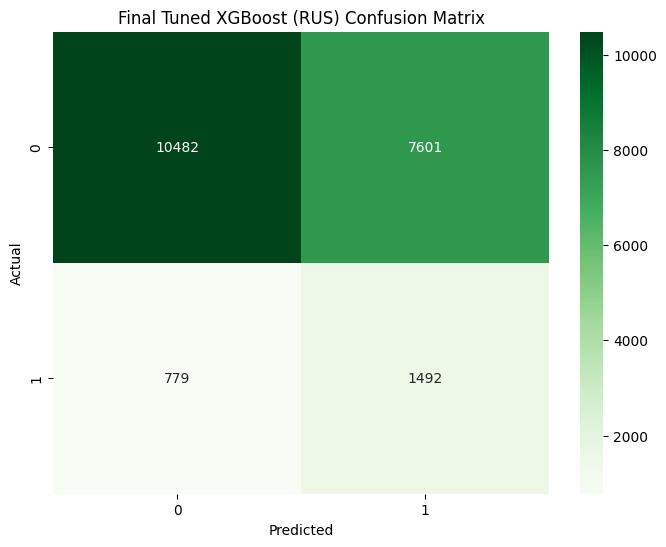

In [ ]:
# Use the best model to predict on the test set
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)

# Print final evaluation metrics
print("Final Classification Report:")
print(classification_report(y_test, y_pred_final))

# Plot the final Confusion Matrix
plt.figure(figsize=(8, 6))
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')
plt.title("Final Tuned XGBoost (RUS) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Advanced Optimization: LightGBM with Adjusted Sampling Ratio

In [ ]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, roc_curve

# 1. Refined Under-Sampling: Instead of 1:1, let's try a 1:2 ratio (minority is 50% of majority)
# This helps improve Precision and overall Accuracy
rus_refined = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_rus_ref, y_rus_ref = rus_refined.fit_resample(X_train, y_train)

# 2. Train LightGBM
lgbm_model = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=5,
                                 num_leaves=31, importance_type='gain', random_state=42)
lgbm_model.fit(X_rus_ref, y_rus_ref)

# 3. Predict and Evaluate
y_pred_opt = lgbm_model.predict(X_test)
y_probs_opt = lgbm_model.predict_proba(X_test)[:, 1]

print("Optimized Model Results:")
print(classification_report(y_test, y_pred_opt))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs_opt):.4f}")

[LightGBM] [Info] Number of positive: 9086, number of negative: 18172
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003523 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 580
[LightGBM] [Info] Number of data points in the train set: 27258, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

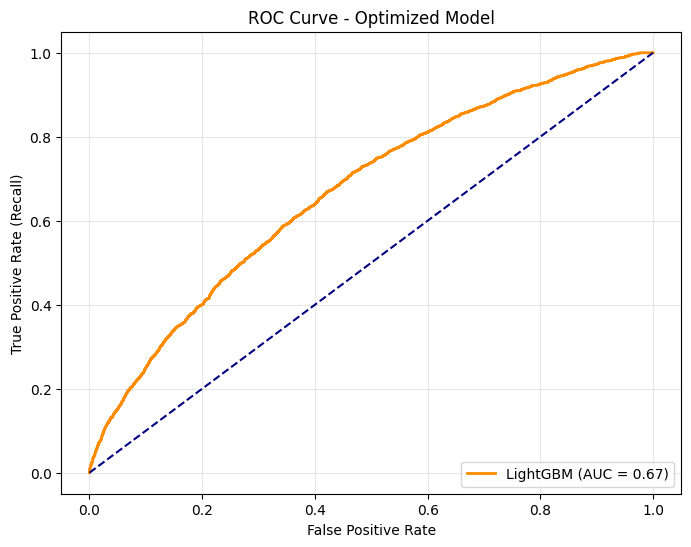

In [ ]:
# Visualize ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs_opt)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {roc_auc_score(y_test, y_probs_opt):.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Optimized Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### Overfitting Check
To confirm if the model is overfitting, we compare the performance on the training set versus the test set.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Predictions on training set
y_train_pred = lgbm_model.predict(X_rus_ref)
# Predictions on test set
y_test_pred = lgbm_model.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_rus_ref, y_train_pred):.4f}")
print(f"Test Accuracy:     {accuracy_score(y_test, y_test_pred):.4f}")
print("-" * 30)
print(f"Training F1 (Class 1): {f1_score(y_rus_ref, y_train_pred):.4f}")
print(f"Test F1 (Class 1):     {f1_score(y_test, y_test_pred):.4f}")

Training Accuracy: 0.7343
Test Accuracy:     0.8379
------------------------------
Training F1 (Class 1): 0.4334
Test F1 (Class 1):     0.2330


# Enhancement: Scaled LightGBM with Class Weight Tuning
In this step, we use `StandardScaler` to normalize features and adjust `scale_pos_weight` in LightGBM to specifically target the minority class recall without losing too much precision.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_rus_ref)
X_test_scaled = scaler.transform(X_test)

# 2. Train LightGBM with scale_pos_weight
# Since we have a 1:2 ratio in X_rus_ref, we can still tune the internal weight
enhanced_lgbm = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    num_leaves=63,
    scale_pos_weight=1.5, # Giving more importance to Class 1
    random_state=42,
    verbosity=-1
)

enhanced_lgbm.fit(X_train_scaled, y_rus_ref)

# 3. Evaluate
y_pred_enh = enhanced_lgbm.predict(X_test_scaled)
print("Enhanced Model Results:")
print(classification_report(y_test, y_pred_enh))

# Compare with previous F1
old_f1 = f1_score(y_test, y_test_pred)
new_f1 = f1_score(y_test, y_pred_enh)
print(f"F1 Score Improvement: {new_f1 - old_f1:.4f}")

Enhanced Model Results:
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     18083
           1       0.20      0.42      0.27      2271

    accuracy                           0.75     20354
   macro avg       0.56      0.61      0.56     20354
weighted avg       0.84      0.75      0.79     20354

F1 Score Improvement: 0.0420


### Saving the Final Enhanced Dataset
We combine the refined features with the target variable and save the result as a CSV for deployment or further analysis.

In [ ]:
# Prepare the final dataframe using the refined features
final_enhanced_df = X_final_refined.copy()
final_enhanced_df['readmitted'] = y

# Save to CSV
final_enhanced_df.to_csv('diabetes_final_enhanced.csv', index=False)

print("Final dataset saved as 'diabetes_final_enhanced.csv'")
display(final_enhanced_df.head())

Final dataset saved as 'diabetes_final_enhanced.csv'


,procedure_intensity,age,insulin,med_intensity,num_lab_procedures,total_visits,inpatient_ratio,time_in_hospital,discharge_disposition_id,number_diagnoses,med_count,readmitted
0,0.000000,5,0,0.500000,41,0,0.00,1,25,1,0.0,0
1,0.000000,15,2,4.500000,59,0,0.00,3,1,9,2.0,0
2,1.666667,25,0,4.333333,11,3,0.25,2,1,6,1.0,0
3,0.333333,35,2,5.333333,44,0,0.00,2,1,7,2.0,0
4,0.000000,45,1,4.000000,51,0,0.00,1,1,5,2.0,0


The final dataset after feature extraction and selection was saved to ensure reproducibility and to provide a clean input for subsequent modeling and evaluation steps.

### Plotting The First 15 Importance Features

In [ ]:
def plot_feature_importance(model, feature_names, model_name):

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    elif hasattr(model, 'get_feature_importance'):
        importances = model.get_feature_importance()
    else:
        print(f"\n[Info] Feature importance visualization not natively supported for {model_name}.")
        return

    if len(feature_names) != len(importances):
        feature_names = [f"Feature {i}" for i in range(len(importances))]

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='magma')
    plt.title(f'Top 15 Feature Importances - {model_name}')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Plotting ROC and Precision Curve

In [ ]:
def plot_roc_curve(y_true, y_scores, model_name, ax=None, combined=False):
    """Plots the Receiver Operating Characteristic (ROC) curve."""
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    if ax is None:
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - {model_name}')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
    else:
        ax.plot(fpr, tpr, lw=2, label=f'{model_name} (area = {roc_auc:.2f})')

def plot_pr_curve(y_true, y_scores, model_name, ax=None, combined=False):
    """Plots the Precision-Recall (PR) curve."""
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)
    if ax is None:
        plt.figure(figsize=(8, 6))
        plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve - {model_name}')
        plt.legend(loc="lower left")
        plt.grid(True)
        plt.show()
    else:
        ax.plot(recall, precision, lw=2, label=f'{model_name} (area = {pr_auc:.2f})')


### Evaluate and Plot The Data Model

In [ ]:
def evaluate_and_plot_model(model, X_train, y_train, X_test, y_test, model_name):
    """Trains a model, evaluates it, prints metrics, and generates plots."""
    print(f"\n---\n--- Evaluating {model_name} ---\n---")

    model.fit(X_train, y_train)

    if hasattr(X_train, 'columns'):
        feature_names = X_train.columns
    else:
        feature_names = [f"Feature {i}" for i in range(X_train.shape[1])]

    # plot_feature_importance(model, feature_names, model_name) # Temporarily commented out to reduce output

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred_default = (y_pred_proba > 0.5).astype(int)

    # Suppress printing individual metrics and plots here
    # print("\nMetrics with Default Threshold (0.5):")
    accuracy_default = accuracy_score(y_test, y_pred_default)
    precision_default = precision_score(y_test, y_pred_default)
    recall_default = recall_score(y_test, y_pred_default)
    f1_default = f1_score(y_test, y_pred_default)
    roc_auc_default = roc_auc_score(y_test, y_pred_proba)
    precision_curve_vals, recall_curve_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc_default = auc(recall_curve_vals, precision_curve_vals)

    # print(f"Accuracy: {accuracy_default:.4f}")
    # print(f"Precision: {precision_default:.4f}")
    # print(f"Recall: {recall_default:.4f}")
    # print(f"F1-Score: {f1_default:.4f}")
    # print(f"ROC-AUC: {roc_auc_default:.4f}")
    # print(f"PR-AUC: {pr_auc_default:.4f}")

    # print(f"\nClassification Report - {model_name} (Default Threshold):")
    # print(classification_report(y_test, y_pred_default))

    # cm = confusion_matrix(y_test, y_pred_default)
    # print(f"\nConfusion Matrix - {model_name} (Raw Numbers, Default Threshold):\n{cm}")

    # plt.figure(figsize=(6, 5))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    #             xticklabels=['Predicted 0', 'Predicted 1'],
    #             yticklabels=['Actual 0', 'Actual 1'])
    # plt.title(f'Confusion Matrix - {model_name} (Default Threshold)')
    # plt.ylabel('Actual Label')
    # plt.xlabel('Predicted Label')
    # plt.show()

    # plot_roc_curve(y_test, y_pred_proba, model_name)

    # plot_pr_curve(y_test, y_pred_proba, model_name)

    return {
        'model_name': model_name,
        'accuracy_default': accuracy_default,
        'precision_default': precision_default,
        'recall_default': recall_default,
        'f1_default': f1_default,
        'roc_auc_default': roc_auc_default,
        'pr_auc_default': pr_auc_default,
        'y_pred_proba': y_pred_proba
    }

### Main Execution


---
--- Evaluating Logistic Regression ---
---

Metrics with Default Threshold (0.5):
Accuracy: 0.6290
Precision: 0.1550
Recall: 0.5222
F1-Score: 0.2390
ROC-AUC: 0.6056
PR-AUC: 0.1565

Classification Report - Logistic Regression (Default Threshold):
              precision    recall  f1-score   support

           0       0.91      0.64      0.75     18083
           1       0.15      0.52      0.24      2271

    accuracy                           0.63     20354
   macro avg       0.53      0.58      0.50     20354
weighted avg       0.83      0.63      0.70     20354


Confusion Matrix - Logistic Regression (Raw Numbers, Default Threshold):
[[11617  6466]
 [ 1085  1186]]


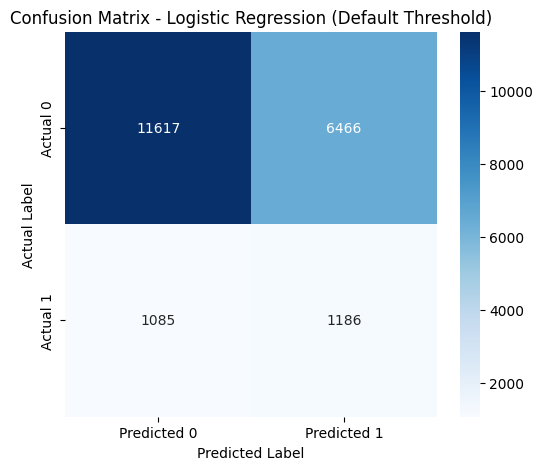

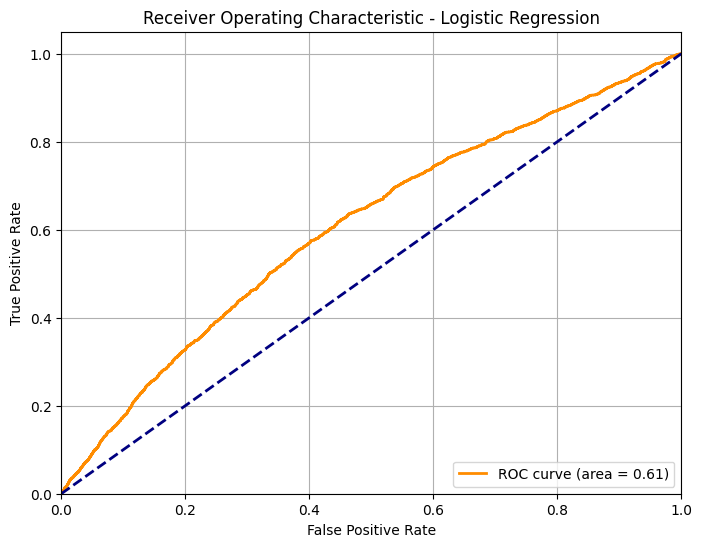

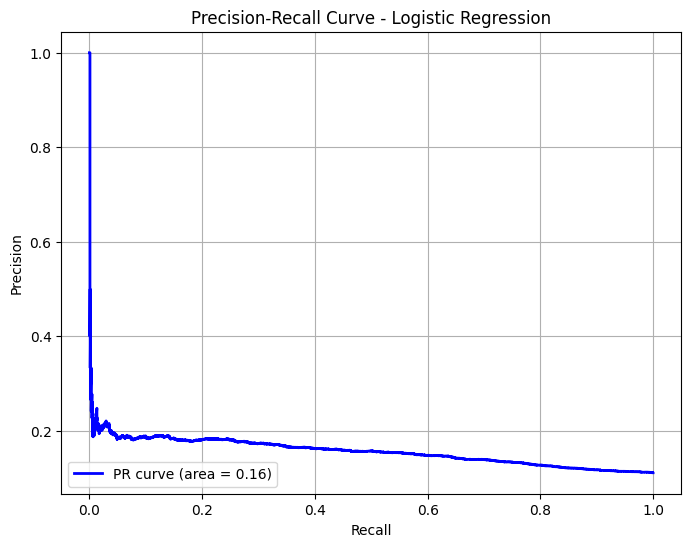


---
--- Evaluating Random Forest ---
---

Metrics with Default Threshold (0.5):
Accuracy: 0.8779
Precision: 0.2774
Recall: 0.0590
F1-Score: 0.0973
ROC-AUC: 0.6192
PR-AUC: 0.1768

Classification Report - Random Forest (Default Threshold):
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     18083
           1       0.28      0.06      0.10      2271

    accuracy                           0.88     20354
   macro avg       0.58      0.52      0.52     20354
weighted avg       0.82      0.88      0.84     20354


Confusion Matrix - Random Forest (Raw Numbers, Default Threshold):
[[17734   349]
 [ 2137   134]]


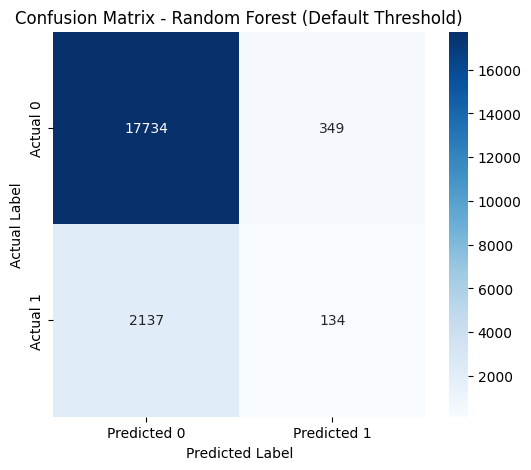

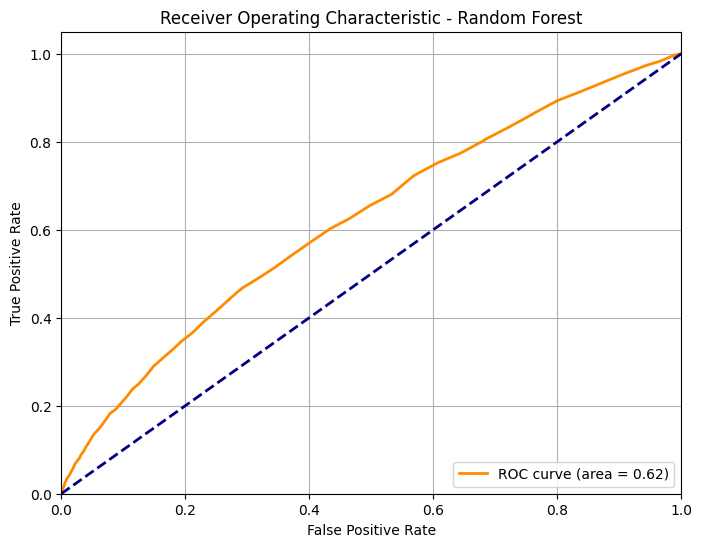

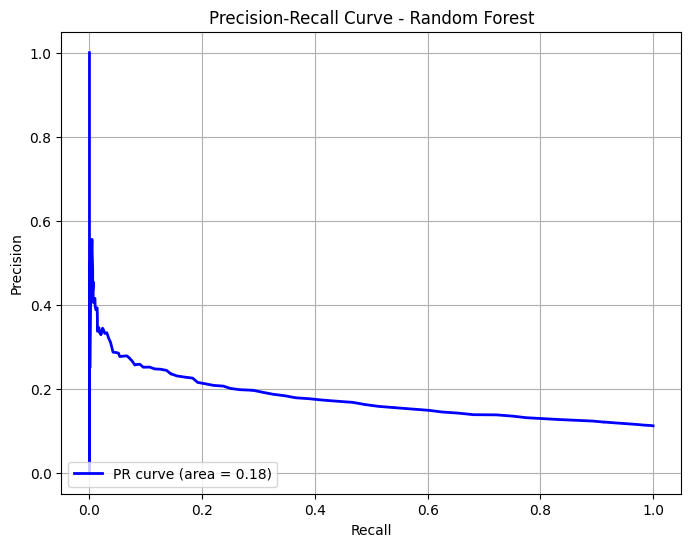


---
--- Evaluating XGBoost ---
---

Metrics with Default Threshold (0.5):
Accuracy: 0.8760
Precision: 0.2860
Recall: 0.0744
F1-Score: 0.1181
ROC-AUC: 0.6351
PR-AUC: 0.1889

Classification Report - XGBoost (Default Threshold):
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     18083
           1       0.29      0.07      0.12      2271

    accuracy                           0.88     20354
   macro avg       0.59      0.53      0.53     20354
weighted avg       0.83      0.88      0.84     20354


Confusion Matrix - XGBoost (Raw Numbers, Default Threshold):
[[17661   422]
 [ 2102   169]]


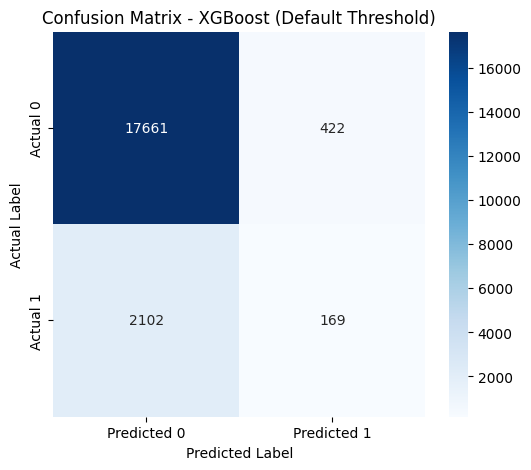

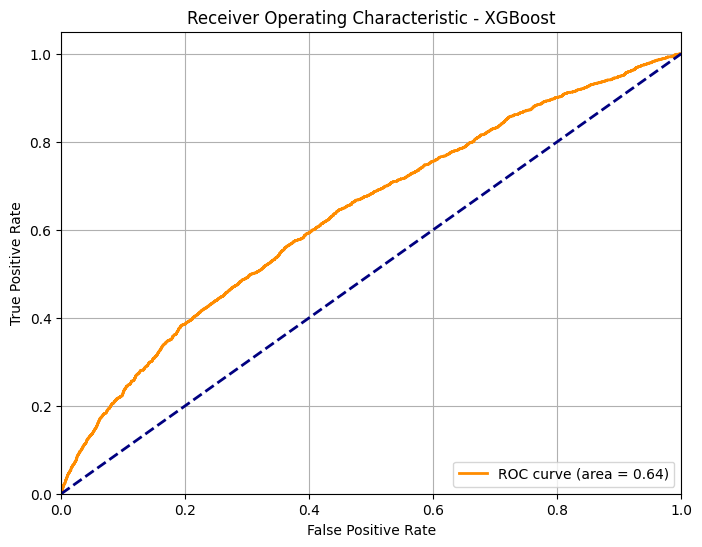

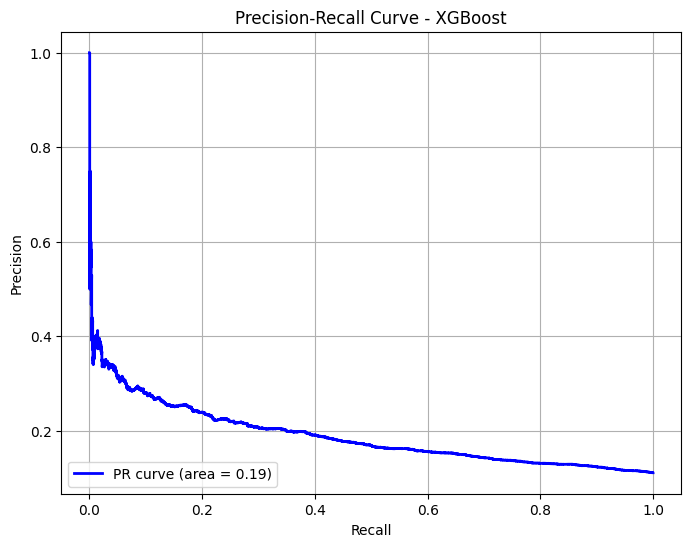


---
--- Evaluating LightGBM ---
---

Metrics with Default Threshold (0.5):
Accuracy: 0.8847
Precision: 0.3468
Recall: 0.0379
F1-Score: 0.0683
ROC-AUC: 0.6501
PR-AUC: 0.1939

Classification Report - LightGBM (Default Threshold):
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18083
           1       0.35      0.04      0.07      2271

    accuracy                           0.88     20354
   macro avg       0.62      0.51      0.50     20354
weighted avg       0.83      0.88      0.84     20354


Confusion Matrix - LightGBM (Raw Numbers, Default Threshold):
[[17921   162]
 [ 2185    86]]


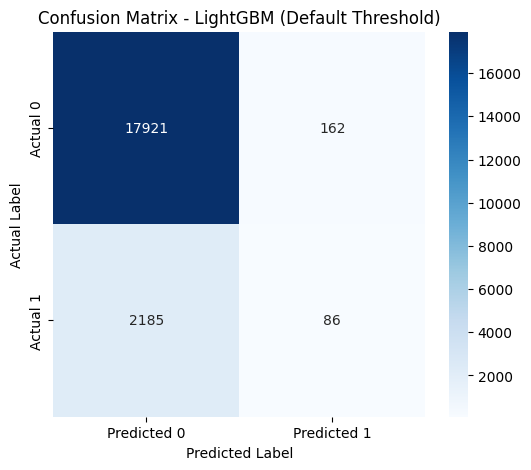

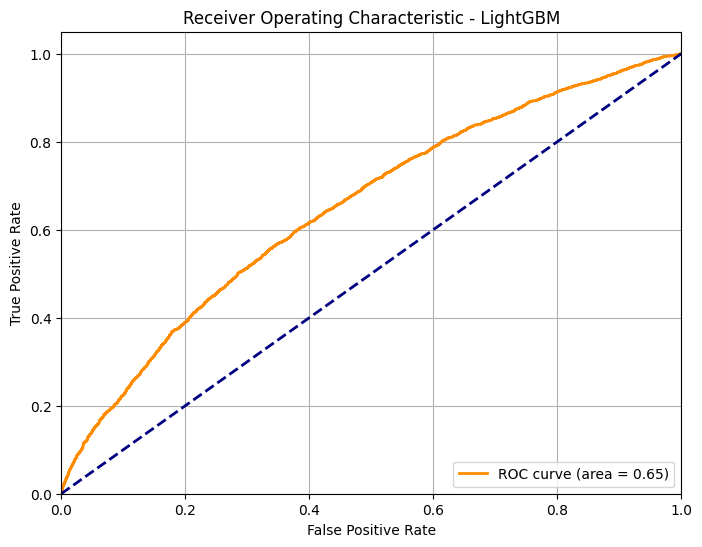

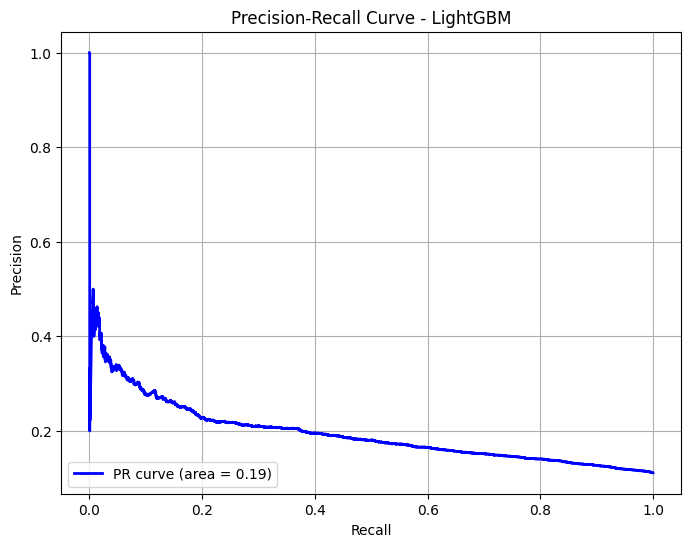


                    Model Comparison Table (Metrics with Default Threshold)
         Model Name  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
Logistic Regression  0.629016   0.154992 0.522237  0.239041 0.605589 0.156454
            XGBoost  0.875995   0.285956 0.074417  0.118099 0.635089 0.188932
      Random Forest  0.877862   0.277433 0.059005  0.097313 0.619239 0.176770
           LightGBM  0.884691   0.346774 0.037869  0.068281 0.650104 0.193879

                    Overall Model Performance Visualizations


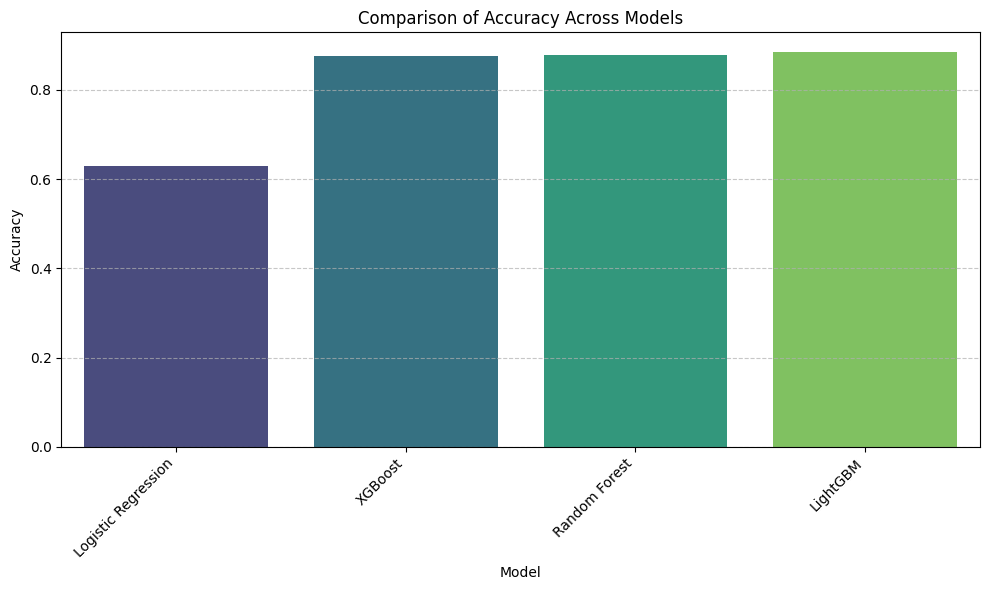

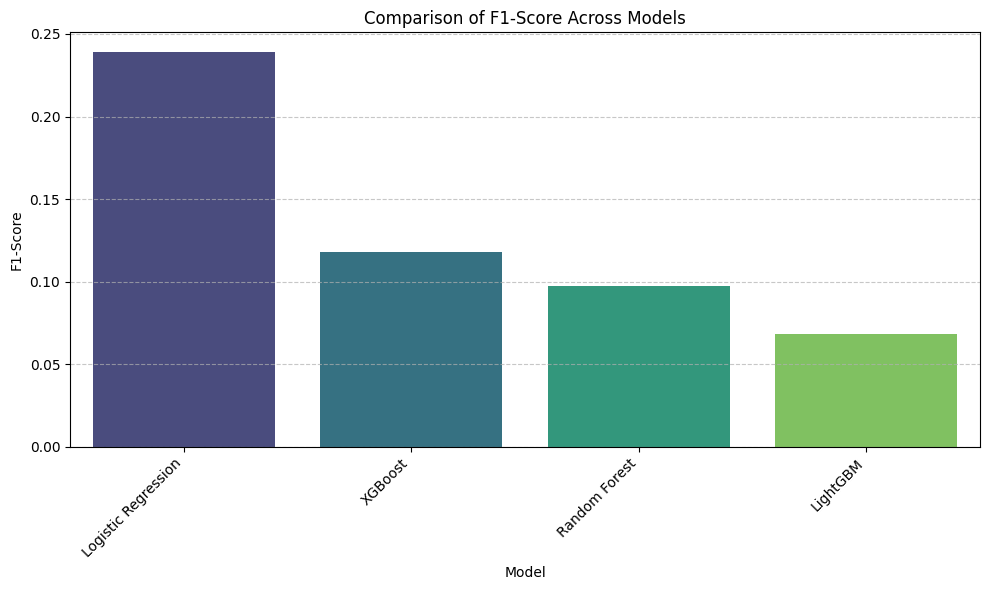

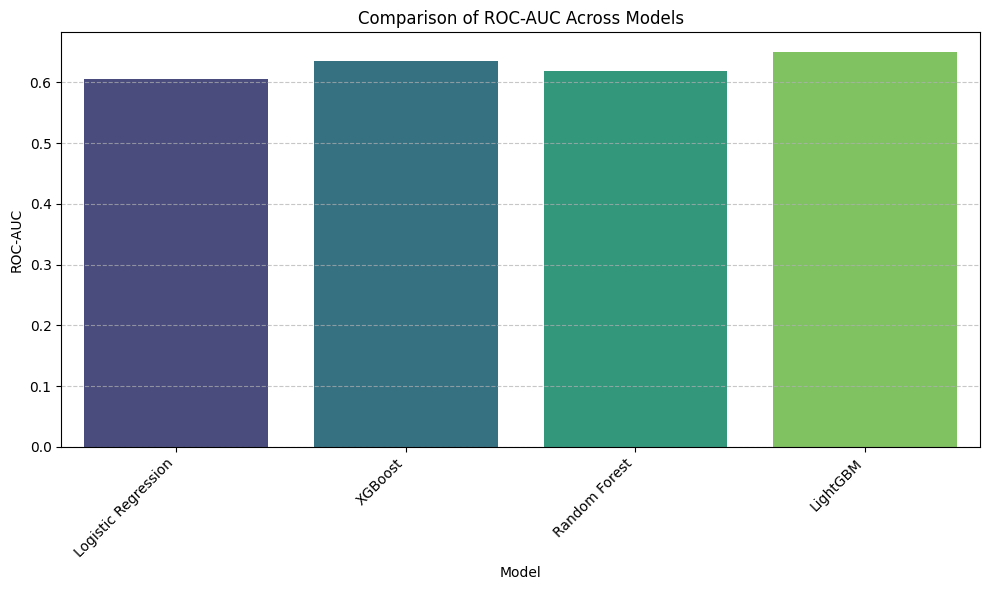

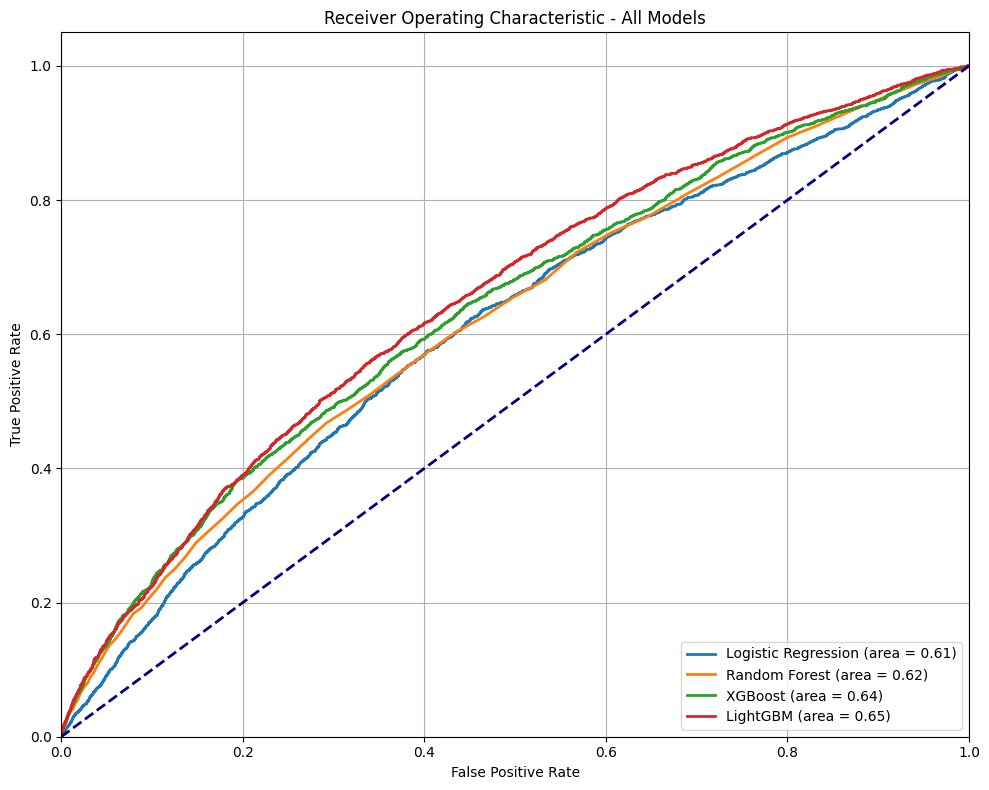

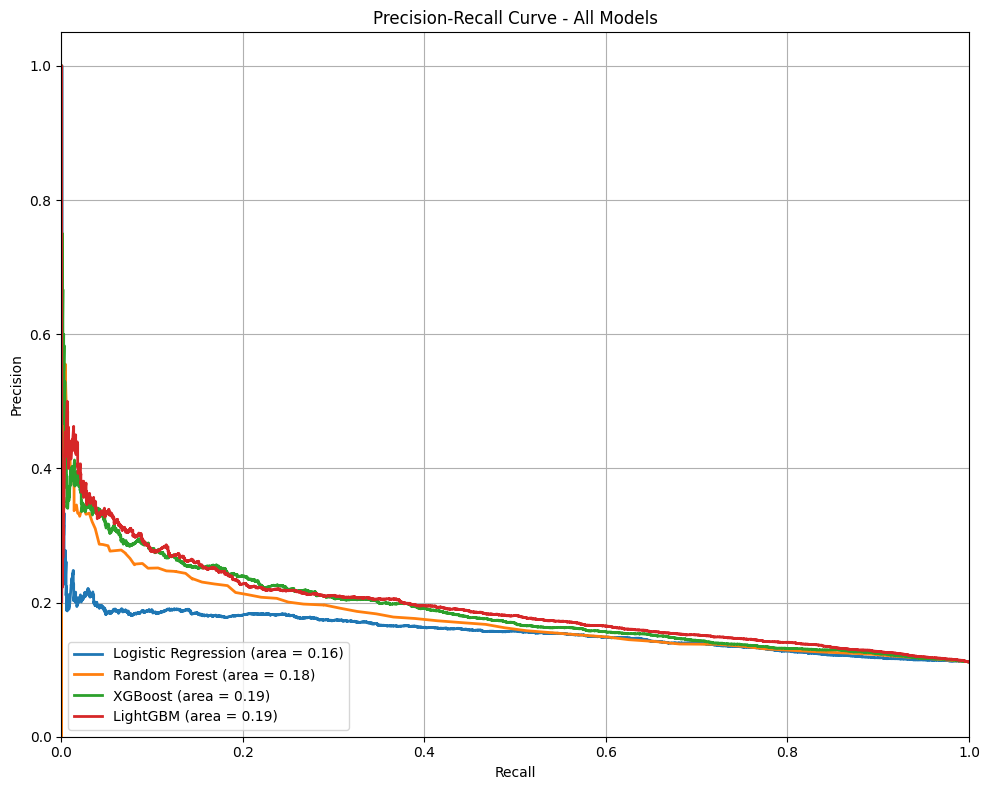

In [ ]:
def main():
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=100, # Reduced for efficiency
            random_state=42
        ),

        "XGBoost": XGBClassifier(
            use_label_encoder=False,
            learning_rate=0.05,
            n_estimators=100, # Reduced for efficiency
            random_state=42
        ),

        "LightGBM": LGBMClassifier(
            learning_rate=0.05,
            n_estimators=100, # Further reduced for efficiency
            num_leaves=31, # Reduced for efficiency
            importance_type='gain',
            random_state=42
            # scale_pos_weight removed as data is SMOTE-balanced
        )
    }

    all_model_results = []


    for model_name, model_obj in models.items():
        # Pass X_smote and y_smote to evaluate_and_plot_model
        results = evaluate_and_plot_model(model_obj, X_smote, y_smote, X_test, y_test, model_name)
        all_model_results.append(results)

    print("\n" + "="*70)
    print(" "*20 + "Model Comparison Table (Metrics with Default Threshold)")
    print("="*70)


    comparison_df = pd.DataFrame([
        {
            'Model Name': res['model_name'],
            'Accuracy': res['accuracy_default'],
            'Precision': res['precision_default'],
            'Recall': res['recall_default'],
            'F1-Score': res['f1_default'],
            'ROC-AUC': res['roc_auc_default'],
            'PR-AUC': res['pr_auc_default']
        }
        for res in all_model_results
    ])

    comparison_df_sorted = comparison_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
    print(comparison_df_sorted.to_string(index=False))

    print("\n" + "="*70)
    print(" "*20 + "Overall Model Performance Visualizations")
    print("="*70)


    metrics_to_plot = ['Accuracy', 'F1-Score', 'ROC-AUC']

    for metric in metrics_to_plot:
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Model Name', y=metric, data=comparison_df_sorted, palette='viridis')
        plt.title(f'Comparison of {metric} Across Models')
        plt.ylabel(metric)
        plt.xlabel('Model')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(10, 8))
    ax_roc = plt.gca()
    for data in all_model_results:
        plot_roc_curve(y_test, data['y_pred_proba'], data['model_name'], ax=ax_roc, combined=True)
    ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('Receiver Operating Characteristic - All Models')
    ax_roc.legend(loc="lower right")
    ax_roc.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    ax_pr = plt.gca()
    for data in all_model_results:
        plot_pr_curve(y_test, data['y_pred_proba'], data['model_name'], ax=ax_pr, combined=True)
    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.05])
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title('Precision-Recall Curve - All Models')
    ax_pr.legend(loc="lower left")
    ax_pr.grid(True)
    plt.tight_layout()
    plt.show()
main()